#### Comparison German (WhatsApp)/Ukrainian (Instagram) 

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
from functools import reduce

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import f1_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')


In [3]:
war_date = pd.to_datetime('2022-02-24')
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

#### Features

In [4]:
features = [
    'donor_daily_message_count',
    'donor_daily_avg_length',
    'daily_active_chats',
    'night_share',
    'words_sent_over_words_received',
    'n_messages_received'
]

#### German WhatsApp data

In [5]:
overview = pd.read_excel(control_data / 'overview-clean-04-AB.xlsx')

In [6]:
overview['min_message_date'] = pd.to_datetime(overview['min_message_date'])
overview['max_message_date'] = pd.to_datetime(overview['max_message_date'])

In [7]:
exclude_dates = [
    'b7a3d9c4-ec90-4241-bc76-f66205049400',  # max = 2069
    '2fa4bc24-8f4d-46f1-ac8e-1deafe7479a5',  # max = 2031
]

In [8]:
valid_donors_de = overview[
    (overview['min_message_date'] <= pre_start) &
    (overview['max_message_date'] >= post_end) &
    (~overview['donation_id'].isin(exclude_dates))
].copy()

print(f'German Donors covering ±6 months: {len(valid_donors_de)}')

valid_donors_de = (
    valid_donors_de
    .sample(n=22, random_state=42)
)['donation_id'].tolist()

print(f'German Donors after random sample: {len(valid_donors_de)}')


German Donors covering ±6 months: 37
German Donors after random sample: 22


In [9]:
df_de = pd.read_csv(control_data / 'text_messages_04-AB.csv')
df_de['datetime'] = pd.to_datetime(df_de['datetime'])
df_de['date'] = df_de['datetime'].dt.date
df_de['hour'] = df_de['datetime'].dt.hour

df_de = df_de[df_de['donation_id'].isin(valid_donors_de)]


In [10]:
donor_sender_de = (
    df_de.groupby(['donation_id', 'sender_id'])['conversation_id']
    .nunique()
    .reset_index()
    .sort_values(['donation_id', 'conversation_id'], ascending=[True, False])
    .groupby('donation_id')
    .first()
    .reset_index()
    .rename(columns={'sender_id': 'donor_sender_id'})
)[['donation_id', 'donor_sender_id']]

df_de = df_de.merge(donor_sender_de, on='donation_id', how='left')
df_de['is_donor'] = (df_de['sender_id'] == df_de['donor_sender_id']).astype(int)


In [11]:
# Top 5 chats determined within ±6-month window only
df_de_window = df_de[
    (df_de['datetime'] >= pre_start) &
    (df_de['datetime'] <= post_end)
]

top5_de = (
    df_de_window.groupby(['donation_id', 'conversation_id'])
    .size()
    .reset_index(name='n_messages')
    .sort_values(['donation_id', 'n_messages'], ascending=[True, False])
    .groupby('donation_id')
    .head(5)
)[['donation_id', 'conversation_id']]

df_de = df_de.merge(top5_de, on=['donation_id', 'conversation_id'], how='inner')

print(f'Donors: {df_de["donation_id"].nunique()}')
print(f'Rows: {len(df_de):,}')
print(f'is_donor: {df_de["is_donor"].value_counts().to_dict()}')


Donors: 22
Rows: 1,218,023
is_donor: {0: 794827, 1: 423196}


Feature Engineering

In [12]:
donor_msg_de = df_de[df_de['is_donor'] == 1].copy()

# donor_daily_message_count
msg_count_de = (
    donor_msg_de.groupby(['donation_id', 'date'])
    .size().reset_index(name='donor_daily_message_count')
)

# donor_daily_avg_length
avg_len_de = (
    donor_msg_de.groupby(['donation_id', 'date'])['word_count']
    .mean().reset_index()
    .rename(columns={'word_count': 'donor_daily_avg_length'})
)

# daily_active_chats
active_chats_de = (
    df_de.groupby(['donation_id', 'date'])['conversation_id']
    .nunique().reset_index()
    .rename(columns={'conversation_id': 'daily_active_chats'})
)

# night_share
donor_msg_de['is_night'] = (
    (donor_msg_de['hour'] >= 0) & (donor_msg_de['hour'] < 6)
).astype(int)
night_share_de = (
    donor_msg_de.groupby(['donation_id', 'date'])['is_night']
    .mean().reset_index()
    .rename(columns={'is_night': 'night_share'})
)

# n_messages_received
received_de = df_de[df_de['is_donor'] == 0]
chat_to_donor_de = (
    df_de[df_de['is_donor'] == 1][['donation_id', 'conversation_id']]
    .drop_duplicates()
    .rename(columns={'donation_id': 'donor_id'})
)
received_with_donor_de = received_de.merge(chat_to_donor_de, on='conversation_id', how='inner')

n_received_de = (
    received_with_donor_de.groupby(['donor_id', 'date'])
    .size().reset_index(name='n_messages_received')
    .rename(columns={'donor_id': 'donation_id'})
)

# words_sent і words_received
words_sent_de = (
    donor_msg_de.groupby(['donation_id', 'date'])['word_count']
    .sum().reset_index()
    .rename(columns={'word_count': 'words_sent'})
)
words_received_de = (
    received_with_donor_de.groupby(['donor_id', 'date'])['word_count']
    .sum().reset_index()
    .rename(columns={'donor_id': 'donation_id', 'word_count': 'words_received'})
)


In [13]:
dfs_de = [
    msg_count_de, avg_len_de, active_chats_de, night_share_de,
    n_received_de, words_sent_de, words_received_de
]

df_features_de = reduce(
    lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'),
    dfs_de
).fillna(0)

df_features_de['words_sent_over_words_received'] = (
    df_features_de['words_sent'] / (df_features_de['words_received'] + 1e-9)
)
df_features_de['date'] = pd.to_datetime(df_features_de['date'])

df_features_de = df_features_de[
    (df_features_de['date'] >= pre_start) &
    (df_features_de['date'] <= post_end)
]

print(f'German Donors: {df_features_de["donation_id"].nunique()}')
print(f'German Rows: {len(df_features_de):,}')


German Donors: 22
German Rows: 5,515


#### Ukrainian Instagram data

In [14]:
exclude_ukr = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa'
]

In [15]:
df_ukr = pd.read_csv(filtered_data / 'text_messages_filtered.csv')
df_ukr['datetime'] = pd.to_datetime(df_ukr['datetime'])
df_ukr['date'] = df_ukr['datetime'].dt.date
df_ukr['hour'] = df_ukr['datetime'].dt.hour

df_ukr = df_ukr[~df_ukr['donation_id'].isin(exclude_ukr)]


In [16]:
# Top 5 chats determined within ±6-month window only
df_ukr_window = df_ukr[
    (df_ukr['datetime'] >= pre_start) &
    (df_ukr['datetime'] <= post_end)
]

top5_ukr = (
    df_ukr_window
    .groupby(['donation_id', 'conversation_id'])
    .size()
    .reset_index(name='n_messages')
    .sort_values(['donation_id', 'n_messages'], ascending=[True, False])
    .groupby('donation_id')
    .head(5)
)[['donation_id', 'conversation_id']]

df_ukr = df_ukr.merge(top5_ukr, on=['donation_id', 'conversation_id'], how='inner')

print(f'Ukrainian Donors: {df_ukr["donation_id"].nunique()}')
print(f'Ukrainian Rows: {len(df_ukr):,}')


Ukrainian Donors: 22
Ukrainian Rows: 508,597


Feature Engineering

In [17]:
donor_msg_ukr = df_ukr[df_ukr['is_donor'] == 1].copy()

msg_count_ukr = (
    donor_msg_ukr.groupby(['donation_id', 'date'])
    .size().reset_index(name='donor_daily_message_count')
)
avg_len_ukr = (
    donor_msg_ukr.groupby(['donation_id', 'date'])['word_count']
    .mean().reset_index()
    .rename(columns={'word_count': 'donor_daily_avg_length'})
)
active_chats_ukr = (
    df_ukr.groupby(['donation_id', 'date'])['conversation_id']
    .nunique().reset_index()
    .rename(columns={'conversation_id': 'daily_active_chats'})
)
donor_msg_ukr['is_night'] = (
    (donor_msg_ukr['hour'] >= 0) & (donor_msg_ukr['hour'] < 6)
).astype(int)
night_share_ukr = (
    donor_msg_ukr.groupby(['donation_id', 'date'])['is_night']
    .mean().reset_index()
    .rename(columns={'is_night': 'night_share'})
)

received_ukr = df_ukr[df_ukr['is_donor'] == 0]
chat_to_donor_ukr = (
    df_ukr[df_ukr['is_donor'] == 1][['donation_id', 'conversation_id']]
    .drop_duplicates()
    .rename(columns={'donation_id': 'donor_id'})
)
received_with_donor_ukr = received_ukr.merge(chat_to_donor_ukr, on='conversation_id', how='inner')

n_received_ukr = (
    received_with_donor_ukr.groupby(['donor_id', 'date'])
    .size().reset_index(name='n_messages_received')
    .rename(columns={'donor_id': 'donation_id'})
)
words_sent_ukr = (
    donor_msg_ukr.groupby(['donation_id', 'date'])['word_count']
    .sum().reset_index()
    .rename(columns={'word_count': 'words_sent'})
)
words_received_ukr = (
    received_with_donor_ukr.groupby(['donor_id', 'date'])['word_count']
    .sum().reset_index()
    .rename(columns={'donor_id': 'donation_id', 'word_count': 'words_received'})
)


In [18]:
dfs_ukr = [
    msg_count_ukr, avg_len_ukr, active_chats_ukr, night_share_ukr,
    n_received_ukr, words_sent_ukr, words_received_ukr
]

df_features_ukr = reduce(
    lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'),
    dfs_ukr
).fillna(0)

df_features_ukr['words_sent_over_words_received'] = (
    df_features_ukr['words_sent'] / (df_features_ukr['words_received'] + 1e-9)
)
df_features_ukr['date'] = pd.to_datetime(df_features_ukr['date'])

df_features_ukr = df_features_ukr[
    (df_features_ukr['date'] >= pre_start) &
    (df_features_ukr['date'] <= post_end)
]

print(f'Ukrainian Donors: {df_features_ukr["donation_id"].nunique()}')
print(f'Ukrainian Rows: {len(df_features_ukr):,}')


Ukrainian Donors: 22
Ukrainian Rows: 5,327


#### Combined Analysis: Comparison Ukrainian vs German

In [19]:
cv_folds = 10

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

In [21]:
def prepare_fold_control(df_features, train_dates, test_dates, features):
    train_raw = df_features[df_features['date'].isin(train_dates)].copy()
    test_raw  = df_features[df_features['date'].isin(test_dates)].copy()

    train_z = train_raw.copy()
    test_z = test_raw.copy()

    for donor_id in df_features['donation_id'].unique():
        mask_train = train_raw['donation_id'] == donor_id
        mask_test = test_raw['donation_id']  == donor_id
        if mask_train.sum() == 0:
            continue
        donor_scaler = StandardScaler()
        train_z.loc[mask_train, features] = donor_scaler.fit_transform(
            train_raw.loc[mask_train, features]
        )
        if mask_test.sum() > 0:
            test_z.loc[mask_test, features] = donor_scaler.transform(
                test_raw.loc[mask_test, features]
            )

    train_avg = train_z.groupby('date')[features + ['label']].mean().reset_index()
    test_avg = test_z.groupby('date')[features + ['label']].mean().reset_index()

    X_train = train_avg[features].values
    y_train = (train_avg['label'] >= 0.5).astype(int).values
    X_test = test_avg[features].values
    y_test = (test_avg['label'] >= 0.5).astype(int).values

    return X_train, y_train, X_test, y_test

In [22]:
def run_combined_full(df_features, features, group_name):
    df_features = df_features.copy()
    df_features['label'] = (df_features['date'] >= war_date).astype(int)

    date_labels = df_features.groupby('date')['label'].first().reset_index()
    date_labels = date_labels.sample(frac=1, random_state=42).reset_index(drop=True)

    all_dates_arr = date_labels['date'].values
    all_labels_arr = date_labels['label'].values

    y_scores = {m: np.zeros(len(all_dates_arr)) for m in models}
    y_true_all = np.zeros(len(all_dates_arr))
    fold_aucs = {m: [] for m in models}
    fold_acc = {m: [] for m in models}
    fold_f1 = {m: [] for m in models}

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(all_dates_arr, all_labels_arr)):
        train_dates = set(all_dates_arr[train_idx])
        test_dates = set(all_dates_arr[test_idx])

        X_train, y_train, X_test, y_test = prepare_fold_control(
            df_features, train_dates, test_dates, features
        )
        y_true_all[test_idx] = y_test

        for model_name, model in models.items():
            clf = clone(model)
            clf.fit(X_train, y_train)
            preds = clf.predict(X_test)
            
            fold_acc[model_name].append(accuracy_score(y_test, preds))
            fold_f1[model_name].append(f1_score(y_test, preds))

            if hasattr(clf, 'decision_function'):
                scores = clf.decision_function(X_test)
            else:
                scores = clf.predict_proba(X_test)[:, 1]
            y_scores[model_name][test_idx] = scores

            fpr_f, tpr_f, _ = roc_curve(y_test, scores)
            fold_aucs[model_name].append(auc(fpr_f, tpr_f))

    roc_results = {}
    for model_name in models:
        fpr, tpr, _ = roc_curve(y_true_all, y_scores[model_name])
        roc_results[model_name] = {
            'fpr': fpr, 'tpr': tpr,
            'auc': auc(fpr, tpr),
            'fold_aucs': fold_aucs[model_name],
            'fold_acc': fold_acc[model_name],
            'fold_f1': fold_f1[model_name],
        }
    return roc_results

In [23]:
roc_ukr = run_combined_full(df_features_ukr, features, 'Ukrainian')
roc_de = run_combined_full(df_features_de, features, 'German')

#### ROC curves — Ukrainian and German

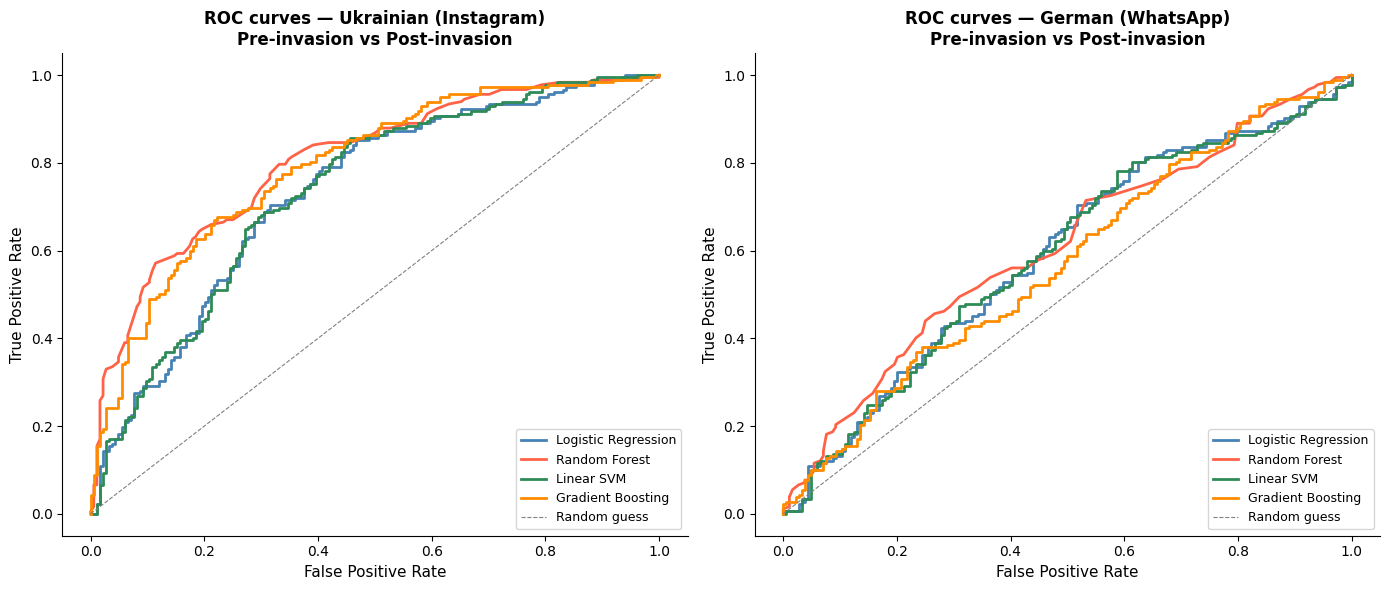

In [24]:
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (roc_results, title) in zip(axes, [
    (roc_ukr, 'Ukrainian (Instagram)'),
    (roc_de, 'German (WhatsApp)'),
]):
    for (model_name, res), color in zip(roc_results.items(), colors):
        ax.plot(res['fpr'], res['tpr'], color=color, linewidth=2,
                label=f'{model_name}')

    ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8,
            linestyle='--', label='Random guess')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC curves — {title}\nPre-invasion vs Post-invasion',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


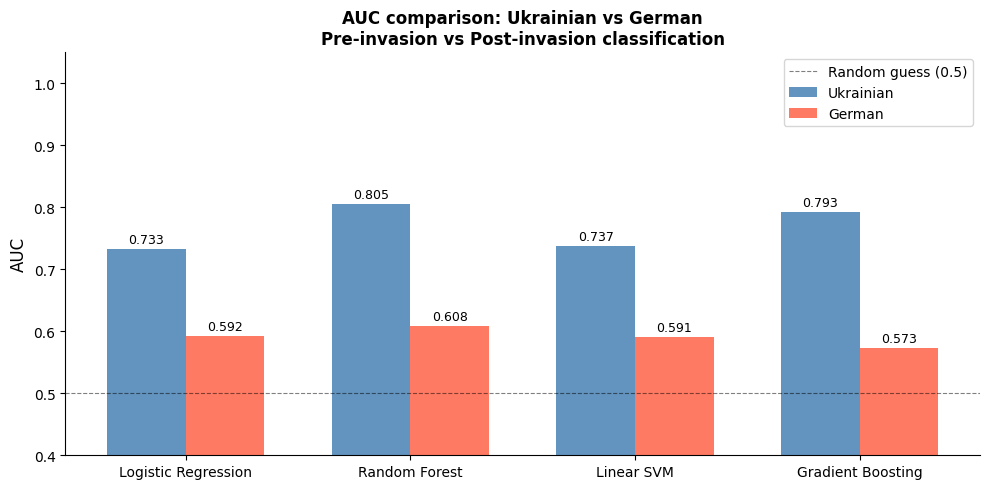

AUC summary:
  Logistic Regression: Ukrainian=0.733, German=0.592, diff=+0.141
  Random Forest: Ukrainian=0.805, German=0.608, diff=+0.197
  Linear SVM: Ukrainian=0.737, German=0.591, diff=+0.146
  Gradient Boosting: Ukrainian=0.793, German=0.573, diff=+0.220


In [25]:
model_names = list(models.keys())
auc_ukr = [roc_ukr[m]['auc'] for m in model_names]
auc_de = [roc_de[m]['auc']  for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_ukr = ax.bar(x - width/2, auc_ukr, width,
                  label='Ukrainian', color='steelblue', alpha=0.85)
bars_de = ax.bar(x + width/2, auc_de,  width,
                  label='German',    color='tomato',    alpha=0.85)

for bar in bars_ukr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_de:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--',
           alpha=0.5, label='Random guess (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('AUC', fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.set_title('AUC comparison: Ukrainian vs German\n'
             'Pre-invasion vs Post-invasion classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('AUC summary:')
for m, u, d in zip(model_names, auc_ukr, auc_de):
    print(f'  {m}: Ukrainian={u:.3f}, German={d:.3f}, diff={u-d:+.3f}')


In [26]:
rows = []
for model_name in model_names:
    for group, roc in [('Ukrainian', roc_ukr), ('German', roc_de)]:
        rows.append({
            'Model': model_name,
            'Group': group,
            'Mean Accuracy': round(np.mean(roc[model_name]['fold_acc']), 3),
            'Std Accuracy': round(np.std(roc[model_name]['fold_acc']), 3),
            'Mean F1': round(np.mean(roc[model_name]['fold_f1']), 3),
            'Std F1': round(np.std(roc[model_name]['fold_f1']), 3),
            'AUC': round(roc[model_name]['auc'], 3),
        })

full_summary = pd.DataFrame(rows).set_index(['Model', 'Group'])
display(full_summary)

Mean Accuracy  Std Accuracy  Mean F1  Std F1  \
Model               Group                                                     
Logistic Regression Ukrainian          0.691         0.081    0.694   0.071   
                    German             0.563         0.071    0.527   0.089   
Random Forest       Ukrainian          0.710         0.056    0.695   0.064   
                    German             0.588         0.082    0.552   0.099   
Linear SVM          Ukrainian          0.683         0.097    0.688   0.086   
                    German             0.563         0.067    0.537   0.075   
Gradient Boosting   Ukrainian          0.716         0.052    0.718   0.061   
                    German             0.530         0.095    0.524   0.094   

                                 AUC  
Model               Group             
Logistic Regression Ukrainian  0.733  
                    German     0.592  
Random Forest       Ukrainian  0.805  
                    German     0.608  
Linear SVM          Ukrainian  0.737  
                    German     0.591  
Gradient Boosting   Ukrainian  0.793  
                    German     0.573